# Module 3: Sampling Distributions and the Central Limit Theorem 🏛️

This is one of the most important concepts in statistics! A **sampling distribution** is the probability distribution of a statistic (like the sample mean) obtained through a large number of samples drawn from a specific population.

The **Central Limit Theorem (CLT)** is a magical result that tells us that, for a large enough sample size, the sampling distribution of the sample mean will be approximately normal, *regardless of the shape of the original population distribution*.

## 3.1 What is a Sampling Distribution?

Imagine you have a population. You don't just take one sample. You take one sample, calculate its mean. Then you take another sample, and calculate its mean. You repeat this thousands of times. The distribution of all those sample means you calculated is the **sampling distribution of the mean**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's re-create our population of 10,000 student heights (normally distributed)
np.random.seed(42)
population_heights = np.random.normal(loc=165, scale=5, size=10000)
population_mean = np.mean(population_heights)
print(f"True Population Mean: {population_mean:.2f}")

# Now, let's simulate the process of creating a sampling distribution.
# We will take 5000 different samples, each of size 30.
num_samples = 5000
sample_size = 30
sample_means = [] # We'll store the mean of each sample here

for i in range(num_samples):
    # Take a random sample from the population
    sample = np.random.choice(population_heights, size=sample_size)
    # Calculate the mean of that sample and append it to our list
    sample_means.append(np.mean(sample))

# The `sample_means` list now contains 5000 sample means. This represents our sampling distribution.
print(f"We have calculated {len(sample_means)} sample means.")

True Population Mean: 164.99
We have calculated 5000 sample means.


### Visualizing the Sampling Distribution

Let's plot a histogram of our original population and a histogram of the sample means we just generated. Notice the differences!

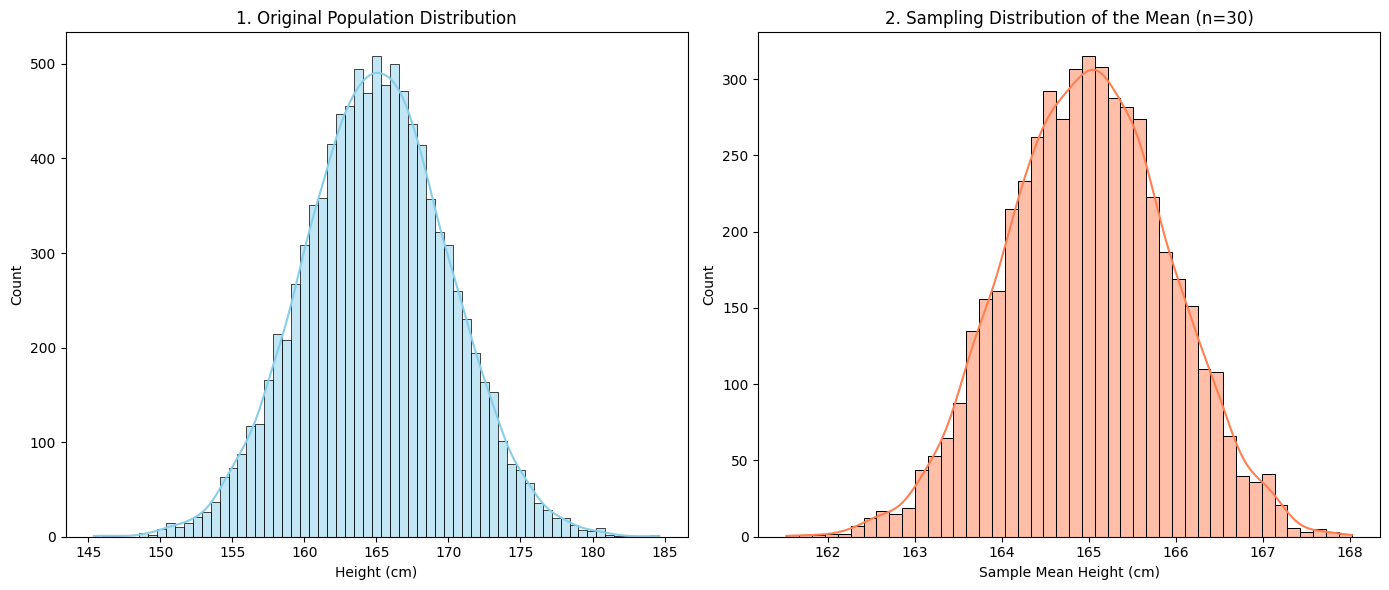

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original population
sns.histplot(population_heights, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('1. Original Population Distribution')
axes[0].set_xlabel('Height (cm)')

# Plot the sampling distribution of the mean
sns.histplot(sample_means, ax=axes[1], color='coral', kde=True)
axes[1].set_title('2. Sampling Distribution of the Mean (n=30)')
axes[1].set_xlabel('Sample Mean Height (cm)')

plt.tight_layout()
plt.show()

# --- Key Observations --- #
# 1. The sampling distribution looks much more like a normal distribution (more bell-shaped).
# 2. The sampling distribution is less spread out than the population distribution.
# 3. The center of the sampling distribution is very close to the center of the original population.

## 3.2 The Central Limit Theorem (CLT) in Action

The CLT is powerful because it works even if the original population is *not* normally distributed. Let's prove this with a heavily skewed distribution, like the exponential distribution.

**Scenario**: Imagine the time between customer arrivals at a store follows an exponential distribution. The distribution is heavily skewed to the right (many short waits, a few very long waits). What will the sampling distribution of the *average* wait time look like?

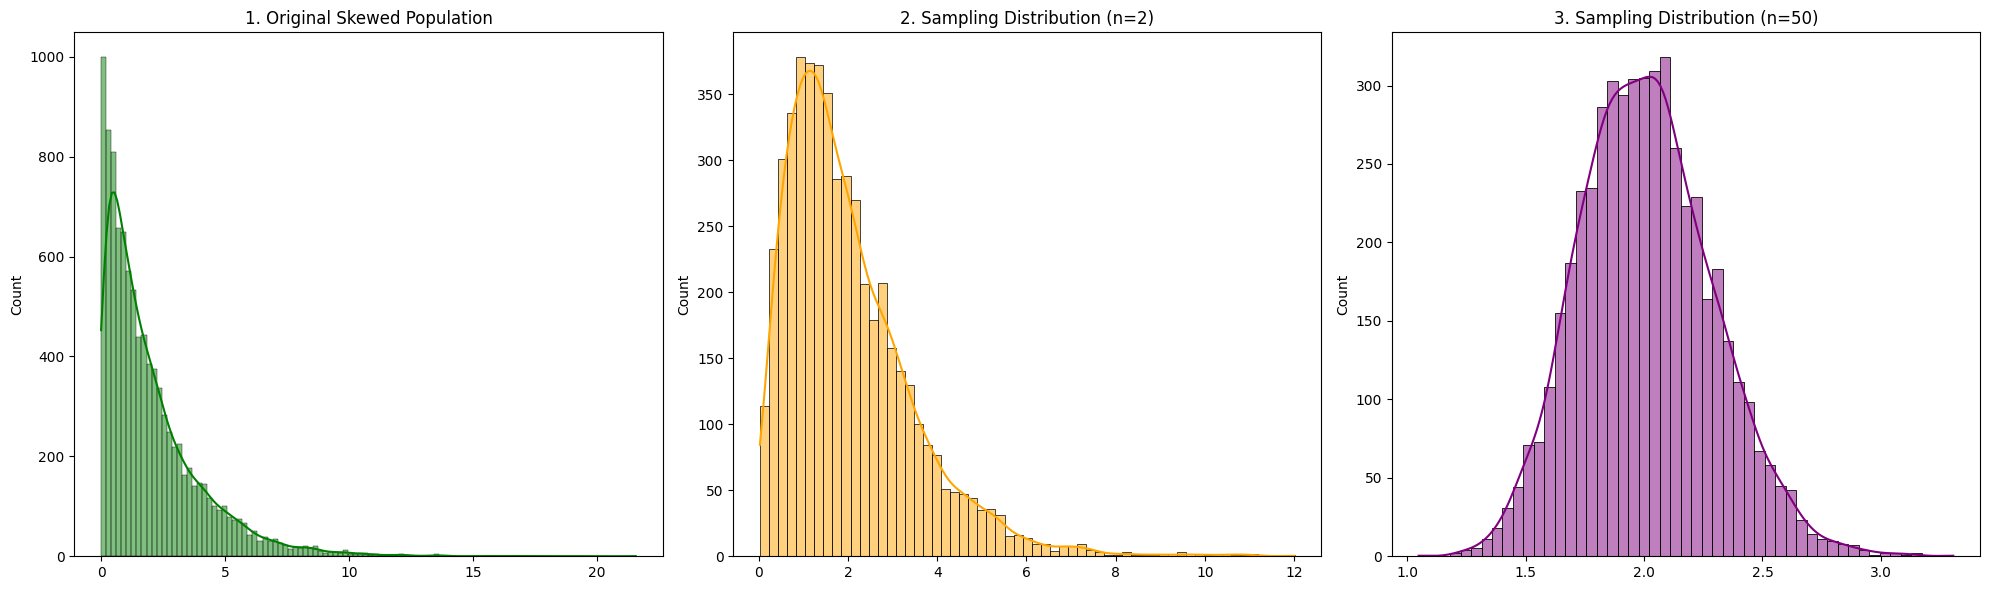

In [3]:
# 1. Create a skewed population (Exponential Distribution)
# Let's say the average time between arrivals is 2 minutes.
np.random.seed(101)
skewed_population = np.random.exponential(scale=2, size=10000)

# 2. Let's take many samples and calculate their means.
# We'll try two different sample sizes: a small one (n=2) and a larger one (n=50).
sample_means_n2 = [np.mean(np.random.choice(skewed_population, size=2)) for _ in range(5000)]
sample_means_n50 = [np.mean(np.random.choice(skewed_population, size=50)) for _ in range(5000)]

# 3. Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: The original skewed population
sns.histplot(skewed_population, ax=axes[0], color='green', kde=True)
axes[0].set_title('1. Original Skewed Population')

# Plot 2: Sampling distribution with a small sample size (n=2)
sns.histplot(sample_means_n2, ax=axes[1], color='orange', kde=True)
axes[1].set_title('2. Sampling Distribution (n=2)')

# Plot 3: Sampling distribution with a larger sample size (n=50)
sns.histplot(sample_means_n50, ax=axes[2], color='purple', kde=True)
axes[2].set_title('3. Sampling Distribution (n=50)')

plt.tight_layout()
plt.show()

# --- The Magic of CLT --- #
# Look at the plots!
# The original population is very skewed.
# The sampling distribution for n=2 is still a bit skewed, but less so.
# The sampling distribution for n=50 looks remarkably like a normal distribution! This is the CLT at work.


### Why is this important? 🤔

Because the sampling distribution of the mean is normal, we can use the properties of the normal distribution to make inferences about the population mean, even when we don't know what the original population looks like. This is the foundation for confidence intervals and hypothesis testing, which we'll cover next.